# **Project 1 - Are Meteorites Becoming More Common?**

### Omar Shatat and Dean Xoubi

## 1. Introduction

## Are Meteorites Becoming More Common?

In [9]:
#Imports here
import pandas as pd
df = pd.read_csv("meteorlandingscsv.csv")
df


,name,id,nametype,recclass,mass,fall,year,reclat,reclong,GeoLocation
0,Aachen,1,Valid,L5,21.0,Fell,1880.0,50.77500,6.08333,"(50.775000, 6.083330)"
1,Aarhus,2,Valid,H6,720.0,Fell,1951.0,56.18333,10.23333,"(56.183330, 10.233330)"
2,Abee,6,Valid,EH4,107000.0,Fell,1952.0,54.21667,-113.00000,"(54.216670, -113.000000)"
3,Acapulco,10,Valid,Acapulcoite,1914.0,Fell,1976.0,16.88333,-99.90000,"(16.883330, -99.900000)"
4,Achiras,370,Valid,L6,780.0,Fell,1902.0,-33.16667,-64.95000,"(-33.166670, -64.950000)"
...,...,...,...,...,...,...,...,...,...,...
45711,Zillah 002,31356,Valid,Eucrite,172.0,Found,1990.0,29.03700,17.01850,"(29.037000, 17.018500)"
45712,Zinder,30409,Valid,"Pallasite, ungrouped",46.0,Found,1999.0,13.78333,8.96667,"(13.783330, 8.966670)"
45713,Zlin,30410,Valid,H4,3.3,Found,1939.0,49.25000,17.66667,"(49.250000, 17.666670)"
45714,Zubkovsky,31357,Valid,L6,2167.0,Found,2003.0,49.78917,41.50460,"(49.789170, 41.504600)"


Personal Motivation: We chose this dataset because we were interested in meteor landings and how the frequency of meteor landings changed over time, and we found this dataset that had many columns. It gave us an abundance of information for what data we were trying to analyze.

Research Question: How is meteorite landing frequency associated with the year?

Contextual Importance: This question yields conclusions that will tell us an important association between the year and the meteorite frequency, so using predictive analysis, we can possibly predict metoerite frequency in the coming years once we find a concrete relationship. This analysis will allow people who study gravity or astronomy to possibly see how modern or industrial practices influence meteorite landing frequency.

## 2. Dataset Discussion

Source: We found our data as a trending dataset on Kaggle, and once we knew that we wanted our analysis to be about meteorite landing, then we found the right one, as the dataset we chose has many useful pieces of information. The link to the dataset is:
https://www.kaggle.com/datasets/nasa/meteorite-landings

Data Collection: According to the dataset's Kaggle page, this data was collected by NASA, specifically by The Meteoritical Society, who collect data on on meteorites that have fallen to Earth from outer space.

In [16]:
df.sample(n = 6)
df.shape

(45716, 10)

Unit of Observation: The unit of observation for this data set is one single meteorite landing.

Variables: Some variables of interest would be the year, geolocation, mass, and the meteorite's name.

Think critically: Some limitations that exist within our data include not telling us the direct location and only telling us the geolocation (longitude and latitude). Information that is included in our data are the geolocation (longitude, latitude), mass, year, and name of the meteorite. Again, we are not given the location in the form of a country. We might want to add that information in the form of a country name as an object, rather than having the geolocation in the form of an ordered pair, that would force us to parse through a string and pass both values to a function from an external Python library.

## 3. Dataset Cleaning

In [21]:
df.dtypes

name            object
id               int64
nametype        object
recclass        object
mass           float64
fall            object
year           float64
reclat         float64
reclong        float64
GeoLocation     object
dtype: object

In [22]:
df[df["year"] > 2020] #values that should be taken out because of the years

,name,id,nametype,recclass,mass,fall,year,reclat,reclong,GeoLocation
30679,Northwest Africa 7701,57150,Valid,CK6,55.0,Found,2101.0,0.0,0.00000,"(0.000000, 0.000000)"
38188,Ur,24125,Valid,Iron,NaN,Found,2501.0,30.9,46.01667,"(30.900000, 46.016670)"


In [23]:
df[df["mass"].isna()]

,name,id,nametype,recclass,mass,fall,year,reclat,reclong,GeoLocation
12,Aire-sur-la-Lys,425,Valid,Unknown,NaN,Fell,1769.0,50.66667,2.33333,"(50.666670, 2.333330)"
38,Angers,2301,Valid,L6,NaN,Fell,1822.0,47.46667,-0.55000,"(47.466670, -0.550000)"
76,Barcelona (stone),4944,Valid,OC,NaN,Fell,1704.0,41.36667,2.16667,"(41.366670, 2.166670)"
93,Belville,5009,Valid,OC,NaN,Fell,1937.0,-32.33333,-64.86667,"(-32.333330, -64.866670)"
172,Castel Berardenga,5292,Valid,Stone-uncl,NaN,Fell,1791.0,43.35000,11.50000,"(43.350000, 11.500000)"
...,...,...,...,...,...,...,...,...,...,...
38275,Wei-hui-fu (a),24231,Valid,Iron,NaN,Found,1931.0,NaN,NaN,NaN
38276,Wei-hui-fu (b),24232,Valid,Iron,NaN,Found,1931.0,NaN,NaN,NaN
38278,Weiyuan,24233,Valid,Mesosiderite,NaN,Found,1978.0,35.26667,104.31667,"(35.266670, 104.316670)"
41460,Yamato 792768,28117,Valid,CM2,NaN,Found,1979.0,-71.50000,35.66667,"(-71.500000, 35.666670)"


In [24]:
df[df["reclong"].isna()]

,name,id,nametype,recclass,mass,fall,year,reclat,reclong,GeoLocation
147,Bulls Run,5163,Valid,Iron?,2250.000,Fell,1964.0,NaN,NaN,NaN
208,Clohars,5383,Valid,L4,48.600,Fell,1822.0,NaN,NaN,NaN
409,Jalanash,12068,Valid,Ureilite,700.000,Fell,1990.0,NaN,NaN,NaN
414,Jemlapur,12079,Valid,L6,450.000,Fell,1901.0,NaN,NaN,NaN
585,Maria Linden,15418,Valid,L4,114.000,Fell,1925.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
44000,Yamato 981086,37708,Valid,H4,5.227,Found,1998.0,NaN,NaN,NaN
44001,Yamato 981090,37712,Valid,H4,8.682,Found,1998.0,NaN,NaN,NaN
45589,Yamato 984028,40648,Valid,Martian (shergottite),12.342,Found,1998.0,NaN,NaN,NaN
45660,Yambo no. 2,30346,Valid,L3,3.200,Found,1975.0,NaN,NaN,NaN


In [25]:
df[df["year"].isna()]
df["year"].unique()

array([1880., 1951., 1952., 1976., 1902., 1919., 1949., 1814., 1930.,
       1920., 1974., 1925., 1769., 1838., 1959., 1981., 1957., 2001.,
       1806., 1766., 2002., 1835., 1873., 1860., 1900., 1883., 1899.,
       1969., 2008., 1977., 1895., 1898., 1939.,   nan, 1822., 1869.,
       1942., 1971., 1984., 1914., 1803., 1954., 1932., 1950., 1805.,
       2009., 1923., 1886., 1896., 1933., 1945., 1836., 1865., 1842.,
       1858., 1908., 1855., 1968., 1938., 1934., 1929., 1922., 1907.,
       1993., 1871., 1892., 1913., 1790., 1704., 1904., 1910., 1965.,
       2006., 1994., 2012., 1989., 1916., 1893., 1961., 1937., 1798.,
       2004., 1943., 1924., 1811., 1859., 1921., 1877., 1940., 1905.,
       1827., 1887., 1999., 1843., 1796., 1941., 1906., 1909., 1833.,
       1804., 1962., 1808., 1894., 1852., 1812., 1823., 2003., 2011.,
       1847., 1956., 1960., 1964., 2007., 1990., 1946., 1863., 1861.,
       1870., 1991., 1866., 1973., 1846., 1874., 1791., 1848., 1583.,
       1810., 1988.,

In [81]:
dfclean = df.dropna() 
dfclean
dfclean = dfclean[dfclean["year"] < 2025]
len(dfclean) 

38115

### Let's take a break and recap

So far, we made sure to do some data cleaning to prepare our dataset for analysis. We wanted to make sure the meteorite landings we used had no missing values and were definitely safe to use in our analysis, so we went ahead and located the missing value columns and dropped na values. After that, we removed 2 rows, whose years were 2101 and 2501, because it is pretty self-explanatory, (I do not know why NASA included these meteorites in their dataset, perhaps predicted meteorites?) Overall, our data cleaning process effectively reduced our dataset size from 45,716 to 38,115 observations.

Ultimately, these decisions were made to maintain the integrity of this analysis. Although the data would have probably not skewed at all with the inclusion of those inaccurate year values, taking them out made sure that the data was as accurate as can be.

In [84]:
dfyeargroup = dfclean.groupby("year").agg("count").reset_index()
dfyeargroup
dfyeargroupdatavis = dfyeargroup[dfyeargroup["year"] >= 1900]
dfyeargroupdatavis #dataframe used for data visualization later in the project

,year,name,id,nametype,recclass,mass,fall,reclat,reclong,GeoLocation
139,1900.0,16,16,16,16,16,16,16,16,16
140,1901.0,9,9,9,9,9,9,9,9,9
141,1902.0,12,12,12,12,12,12,12,12,12
142,1903.0,22,22,22,22,22,22,22,22,22
143,1904.0,11,11,11,11,11,11,11,11,11
...,...,...,...,...,...,...,...,...,...,...
248,2009.0,1496,1496,1496,1496,1496,1496,1496,1496,1496
249,2010.0,1005,1005,1005,1005,1005,1005,1005,1005,1005
250,2011.0,713,713,713,713,713,713,713,713,713
251,2012.0,234,234,234,234,234,234,234,234,234


In [28]:
dfyeargroup["name"].describe() #describes the number of meteorites that happens per year. 
#For example the mean number of meteorites that landed in a single year is 150

count     253.000000
mean      150.652174
std       421.118708
min         1.000000
25%         3.000000
50%        11.000000
75%        23.000000
max      3045.000000
Name: name, dtype: float64

In [88]:
dfclean.sort_values("year")
df1900s = dfclean[(dfclean["year"] >= 1900) & (dfclean["year"] <= 1950)] #the subset with observations of meteorites from 1900 - 1950.
df1900s["year"].unique()
df1900sgrouped = df1900s.groupby("year").agg("count").reset_index()
mean1900s = df1900sgrouped["name"].mean()
mean1900s
print(mean1900s, "is the mean number of meteorites per year from 1900 - 1950 (50 year period)")

18.941176470588236 is the mean number of meteorites per year from 1900 - 1950 (50 year period)


In [86]:
dfrecent = dfclean[dfclean["year"] >= 1963]
dfrecent #the subset with observations of meteorites from 1963 - 2013.
dfrecentgrouped = dfrecent.groupby("year").agg("count").reset_index()
dfrecentmean = dfrecentgrouped["name"].mean()
dfrecentmean
print(dfrecentmean, "is the mean number of meteorites per year from 1963 - 2013 (50 year period)")

709.5686274509804 is the mean number of meteorites per year from 1963 - 2013 (50 year period)


## 4. Summarizing Data

What is the association between frequency of meteorite landings and the year?

<Axes: xlabel='year'>

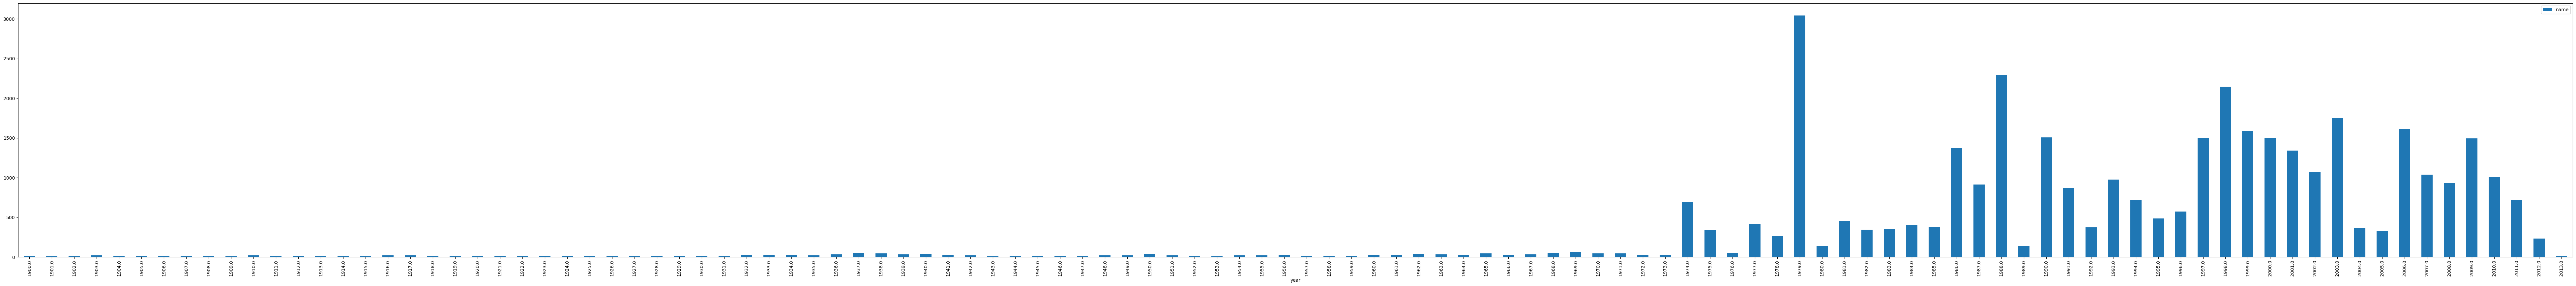

In [99]:
dfyeargroupdatavis.plot.bar(x = "year", y = "name", figsize = (100, 10))

In [34]:
df1900sgrouped["name"].describe()
dfrecentgrouped["name"].describe()

count      51.000000
mean      709.568627
std       703.128502
min        11.000000
25%       101.000000
50%       420.000000
75%      1052.000000
max      3045.000000
Name: name, dtype: float64

If you take a look at our data visualization (do not mind the x-axis labelling), you will see a graph that displays the frequency of meteorite landings from the year 1900 to 2013 (x-axis). As you can see, the left side of the graph looks extremely flat and low (our data shows that there were in fact minimal number of meteorites, not completely flat), signifying an extremely low frequency of meteorite landings, while the right side of the graph, which shows the more recent years, sees astronomical spikes in terms of meteorite frequency, indicating the frequency is drastically different based on the year. 

Although NASA's Meteoritical Society tracks meteorites dating all the way back to the year 601 AD, we thought that comparing two time periods with similar available technologies would be best, to avoid the problem of our data being skewed by the fact that The Meteoritical Society and modern technology was not developed back then to track all the meteorites that might have landed, so we chose 1900-1950 as our control group, given that The Meteoritical Society was developed in the early 1900s.

Furthermore, if you look at the next code block, we give concise summaries that tell you all you need to know about meteorite landing frequency during that time period. The first line gives us a straight-to-the-point table with useful information, like the mean and median numbers of meteorite landings per year during 1900 - 1950, and the second line does the same for the recent 50-year time period from 1963 - 2013, even giving us shocking information like 3045 being the most meteorite landings in a single year during that period!

Our results give us a definite answer to our research question, because of two very important values we calculated, which were the mean number of meteorite landings for each time period, and the results were actually quite shocking. We calculated that the mean number of meteorite landings per year for the 1900-1950 period, was almost 19 meteorites per year, while the mean for the 1963-2013 period was a whopping 709 meteorites per year. This shows without a doubt, that yes, there is an association between year and meteorite landing frequency. According to our analysis, the higher the year, the higher the meteorite landings.

Not to mention, these results and calculations might be able to help us predict the rates of meteorite landing frequency in the future, with the help of simple linear regression!

## Any other type of analysis/question you want to explore with this dataset.

<u>Why?</u>: Sometimes undergraduate students will put the research projects that they did for their classes on their resumes when applying for graduate schools, internships, and jobs. If you're interested in showcasing cool analyses to write on your resume, this section could help with that. **(This section is not worth any points though).**

How does geolocation relate to frequency of meteorite landings?

Are the development levels of certain areas associated at all with meteorite landings?

## 5. Conclusion

## Conclusion Goes Here

To summarize our findings, we utilized a comprehensive dataset on Kaggle that consisted of NASA's findings, specifically The Meteoritical Society, in regards to meteorite landings around the world. Although the dataset ranged from the year 601 - 2100, we decided to do some data cleaning to filter the data, removing NaN values and implausible values, (the years over 2025). With this data set, whose unit of observation was one single meteorite landing, we decided to create a very discrete and specialized analysis, where we compared the meteorite landing rates in the period from 1900-1950, and 1963-2013. At the end, we found very concrete evidence that suggests that the more modern or recent the year, the higher the meteorite landing frequency.

Although there were some limitations throughout the dataset, like the inclusion of implausible values, we decided to clean it and provide a sufficient analysis to produce a conclusion. Before, however, we could make a concrete claim, we had to search for some contextual information that would prove our analysis to be accurate. Some of this information includes the founding of NASA's Meteoritical Society and the years of their operations and investigations done actively by The Meteoritical Society.

As far as the future, this analysis can help many people, who are either interested in astronomy, or more broad natural processes that might have influenced our findings, like the atmosphere, gravity, etc. There are still many questions that can be answered with our dataset, because we have useful information like the geolocation of the meteorite landing, perhaps for Project 2? Thanks for reading!